# **1) Problem Statement**

## The goal of this project is to develop a neural network model using PyTorch and TensorFlow to predict Uber ride fare prices based on trip features such as pickup and drop-off locations, distance, passenger count, and time-related information. The model aims to learn patterns in historical ride data to accurately estimate the fare amount for new trips.

# 2) **Data Acquisition**

In [2]:
# mount with google colab

from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [14]:
# change working directory
import os
os.chdir('/content/drive/MyDrive//BigData/Projects_dataset/Uber/Uber')

In [15]:
# read some data from test
import pandas as pd
data = pd.read_csv('train.csv', sep= r'\s+')
data.head(5)

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,Distance,month_1,month_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,-0.288820,-0.142162,0.135856,-0.139290,0.138253,-0.493901,0.138727,-0.046622,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,3.94540,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
1,-0.490802,-0.143644,0.137394,-0.142144,0.135555,2.392110,1.216060,-0.050553,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,4.140370,-0.227047
2,-0.894768,-0.142009,0.131986,-0.141677,0.131921,-0.493901,-0.938608,-0.053531,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
3,-0.490802,-0.141974,0.133379,-0.141377,0.135372,2.392110,-1.477280,-0.049876,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,4.404370
4,0.266632,-0.143593,0.134052,-0.144410,0.127990,3.113610,1.216060,-0.043614,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047


# **3) Exploratory Data Analysis (EDA)**

In [17]:
import matplotlib.pyplot as plt

# data shape
print(f'Data shape: {data.shape}')

Data shape: (159990, 51)


In [22]:
# features type
print(f'Data types:\n{data.dtypes}')

Data types:
fare_amount          float64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count      float64
year                 float64
Distance             float64
month_1              float64
month_2              float64
month_3              float64
month_4              float64
month_5              float64
month_6              float64
month_7              float64
month_8              float64
month_9              float64
month_10             float64
month_11             float64
month_12             float64
weekday_0            float64
weekday_1            float64
weekday_2            float64
weekday_3            float64
weekday_4            float64
weekday_5            float64
weekday_6            float64
hour_0               float64
hour_1               float64
hour_2               float64
hour_3               float64
hour_4               float64
hour_5               float64
hour_6               float64
ho

In [26]:
# missing values
print(f'Missing values:\n{data.isnull().sum()}')

Missing values:
fare_amount          0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
year                 0
Distance             0
month_1              0
month_2              0
month_3              0
month_4              0
month_5              0
month_6              0
month_7              0
month_8              0
month_9              0
month_10             0
month_11             0
month_12             0
weekday_0            0
weekday_1            0
weekday_2            0
weekday_3            0
weekday_4            0
weekday_5            0
weekday_6            0
hour_0               0
hour_1               0
hour_2               0
hour_3               0
hour_4               0
hour_5               0
hour_6               0
hour_7               0
hour_8               0
hour_9               0
hour_10              0
hour_11              0
hour_12              0
hour_13              0
hour_14              0
hour_15           

In [30]:
# feature statistics
print(f'Feature statistics:\n{data.describe()}')

Feature statistics:
         fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  159990.000000     159990.000000    159990.000000      159990.000000   
mean       -0.002188         -0.000980         0.000732          -0.001021   
std         0.996628          0.997243         1.000790           0.997072   
min        -6.398790         -2.040480       -18.585000          -0.279621   
25%        -0.541298         -0.142608         0.133254          -0.142121   
50%        -0.288820         -0.141629         0.136150          -0.141031   
75%         0.115145         -0.140221         0.138537          -0.139452   
max        49.247400         10.842900         1.217770          10.885700   

       dropoff_latitude  passenger_count           year       Distance  \
count     159990.000000    159990.000000  159990.000000  159990.000000   
mean           0.000813         0.000851      -0.002003       0.000812   
std            1.000570         1.014864       1.000067

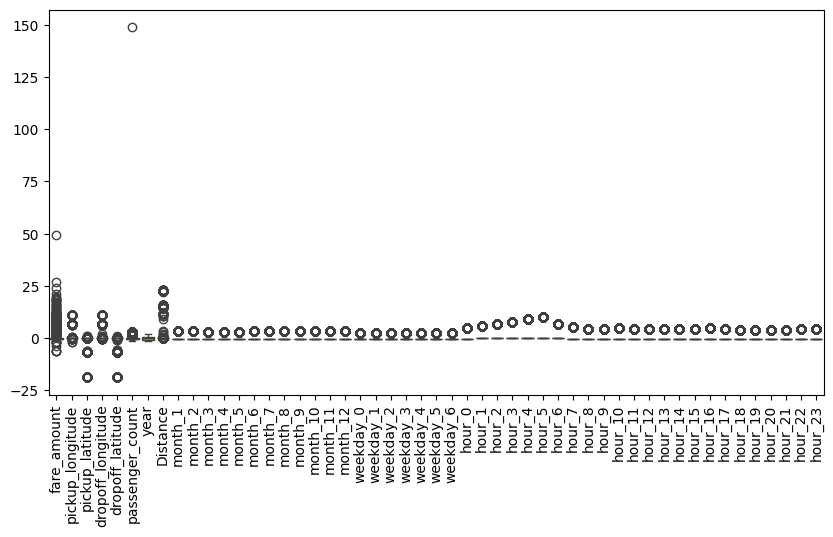

In [34]:
# Box plot
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

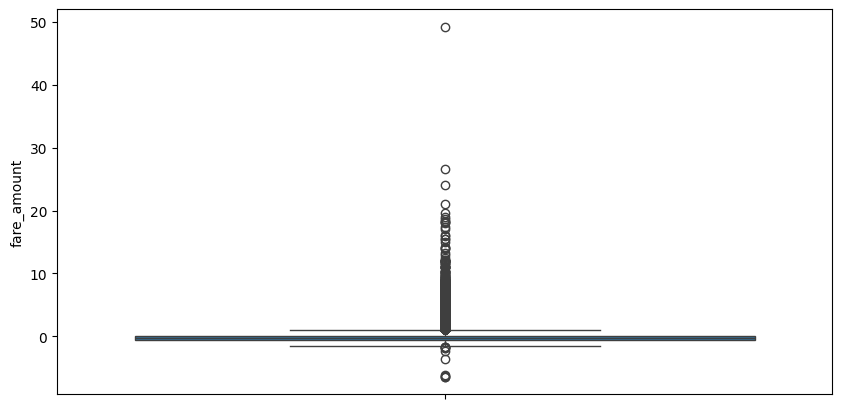

In [35]:
# Box plot target variable
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=data['fare_amount'])
plt.xticks(rotation=90)
plt.show()

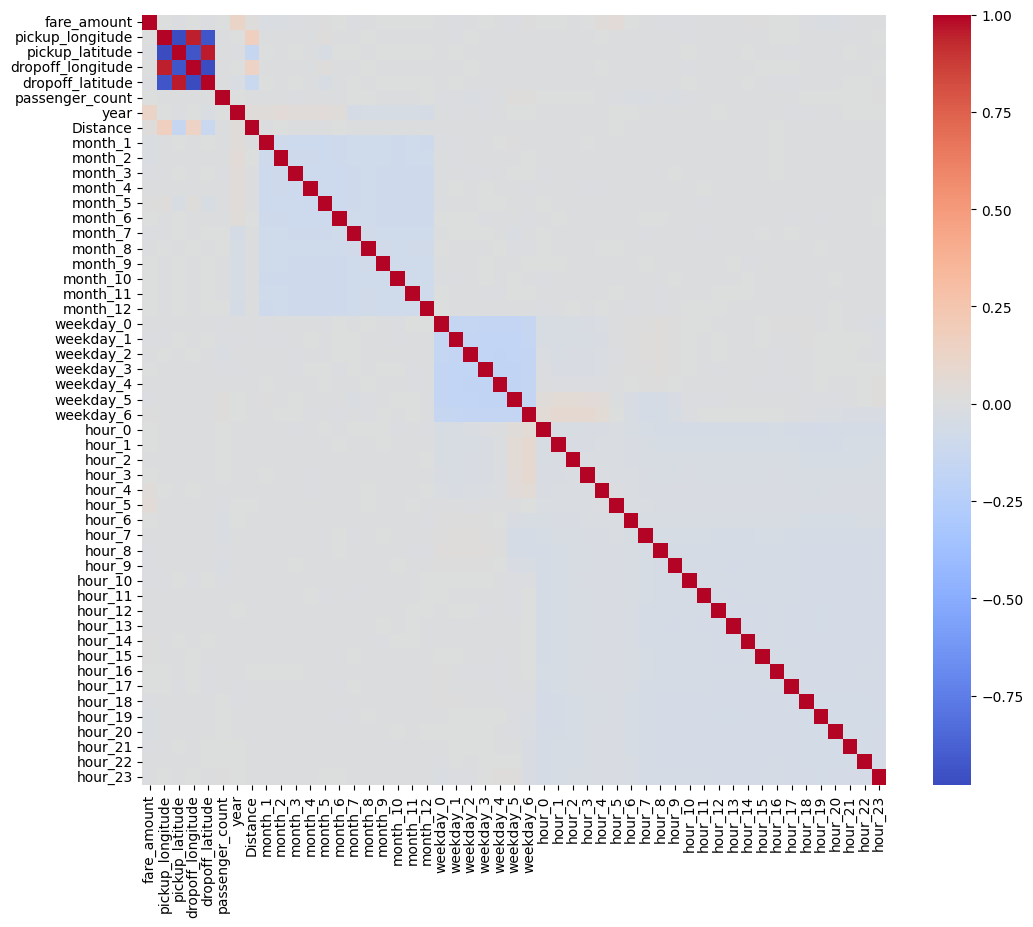

In [36]:
# 7. Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()

# **4) Feature Selection**

In [43]:
# remove negative and zero prices
newData = data[data['fare_amount'] > 0]

<Axes: ylabel='fare_amount'>

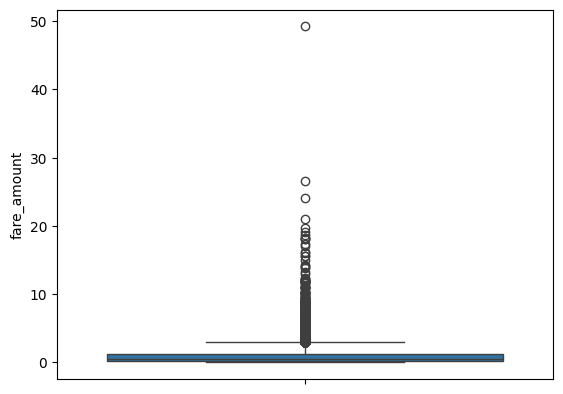

In [38]:
sns.boxplot(data=newData['fare_amount'])

<Axes: ylabel='fare_amount'>

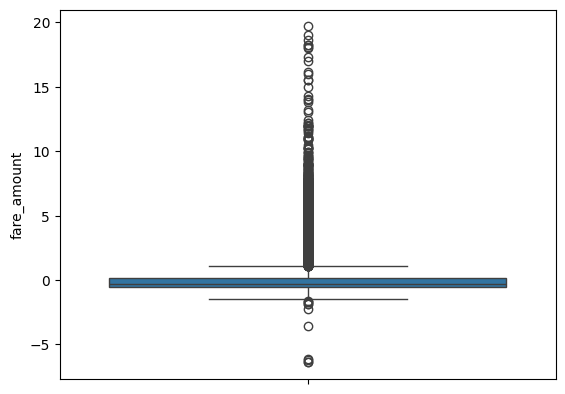

In [44]:
# remove outlier values
newData = data[data['fare_amount'] < 20]
sns.boxplot(data=newData['fare_amount'])

In [65]:
# final pre processing function

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def preprocess_fare_and_pca(train, val, test, price_col="fare_amount", pca_var=0.95):

    # -----------------------------
    # 1. CLEANING RULE (from train)
    # -----------------------------
    def clean(df):
        return df[(df[price_col] >= 0) & (df[price_col] <= 23)]

    train_clean = clean(train)
    val_clean   = clean(val)
    test_clean  = clean(test)

    # -----------------------------
    # 2. SPLIT INTO X AND y
    # -----------------------------
    X_train = train_clean.drop(columns=[price_col])
    y_train = train_clean[price_col]

    X_val = val_clean.drop(columns=[price_col])
    y_val = val_clean[price_col]

    X_test = test_clean.drop(columns=[price_col])
    y_test = test_clean[price_col]

    # -----------------------------
    # 3. SCALING (fit on train only)
    # -----------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    # -----------------------------
    # 4. PCA (fit on train only)
    # -----------------------------
    pca = PCA(n_components=pca_var)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca   = pca.transform(X_val_scaled)
    X_test_pca  = pca.transform(X_test_scaled)

    return X_train_pca, y_train, X_val_pca, y_val, X_test_pca, y_test, scaler, pca

In [66]:
train = pd.read_csv('train.csv', sep= r'\s+')
test = pd.read_csv('test.csv', sep= r'\s+')
val = pd.read_csv('val.csv', sep= r'\s+')

In [70]:
X_train_pca, y_train, X_val_pca, y_val, X_test_pca, y_test, scaler, pca =  preprocess_fare_and_pca(train, val, test)

# **6) Network**

In [79]:
#set working env to gpu
device = 'cuda'
learning_rate = 0.00001
batch_size = 50

In [80]:
# How data loaded during training and validation

import torch
# create train dataloader
train_dl = torch.utils.data.DataLoader(
    X_train_pca,
    batch_size = batch_size,
    drop_last = True,
    shuffle = True,
    num_workers = 2
)
# create validation dataloader
val_dl = torch.utils.data.DataLoader(
    X_val_pca,
    batch_size = batch_size,
    drop_last = False,
    shuffle = False,
    num_workers = 2
)

In [82]:
# define network

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter

class Net(nn.Module):

    def __init__(self):
        # initialize super class
        super(Net, self).__init__()
        self.layer1 = nn.Linear(50,128)
        self.layer2 = nn.ReLU()
        self.layer3 = nn.Linear(128,64)
        self.layer4 = nn.ReLU()
        self.layer5 = nn.Linear(64,32)
        self.layer6 = nn.ReLU()
        self.layer7 = nn.Linear(32,16)
        self.layer8 = nn.ReLU()
        self.layer9 = nn.Linear(16, 1)


    def forward(self, x):
        # apply layers in cascade
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = self.layer7(x)
        x = self.layer8(x)
        x = self.layer9(x)
        # return output
        return x

In [84]:
# let's move the network in GPU
net = Net()
net.to(device)

# define random batch of 10 elements
inp = torch.rand(10, 50)

# move the batch in GPU
inp = inp.to(device)

# get the output
out = net(inp)

# let's print the shape
print(' Input shape is', inp.shape)
print('Output shape is', out.shape)

AssertionError: Torch not compiled with CUDA enabled